# TFI 1: Mejora y restauracion de imagenes

**Modalidad:** trabajo en parejas con defensa oral breve e individual.

**Entrega:** notebook completo + carpeta de imagenes originales + carpeta de resultados procesados.

En este Trabajo Final Integrador vas a reunir tecnicas vistas en las unidades de bibliotecas basicas de PDI y vision por computadora para resolver tres casos obligatorios. La idea no es aplicar filtros de manera automatica, sino leer un problema visual, comparar estrategias y justificar una decision tecnica.

Los tres casos son:

1. imagen obtenida mediante camara oscura;
2. imagen de medio grafico color;
3. imagen de medio grafico blanco/negro.


## Objetivo

Construir tres pipelines acotados de mejora y restauracion, comparar alternativas por caso y sostener una eleccion final con evidencia visual y criterio tecnico.

## Resultados de aprendizaje esperados

Al finalizar este trabajo, vas a poder:

- diagnosticar problemas frecuentes de contraste, ruido, perspectiva e iluminacion;
- elegir operaciones pertinentes segun el tipo de imagen;
- justificar parametros y descartar estrategias poco adecuadas;
- comparar resultados sin reducir la decision a "queda mejor";
- explicar limites tecnicos de una restauracion digital.

## Relacion con la secuencia

Este TFI recupera y combina ideas trabajadas en `003 - librerias_fundamentos_pdi` y `004 - computer_vision_parte_1`: diagnostico inicial, ajuste de brillo y contraste, `CLAHE`, cambio de perspectiva, suavizado, umbralizacion, morfologia e `inpainting`.


## Trabajo con IA

Podes usar IA como apoyo para discutir alternativas, revisar errores de codigo o auditar una decision tecnica. Pero no vale usarla como reemplazo de tu criterio. Toda seleccion de parametros, toda justificacion y toda version entregada tienen que quedar bajo tu responsabilidad.

### Registro breve del uso de IA

Completa al menos una entrada por caso.

| Caso | Objetivo de la consulta | Pedido a la IA | Que conservaste y por que | Que descartaste y por que | Que aprendiste |
|---|---|---|---|---|---|
| Camara oscura |Corregir el código de la edición inicial de la imagen (quedaba mal recortada) y explicación / Potencialidades de CLAHE y mejoras para el brillo y contraste|Revisar por qué, a pesar de la corrección de los valores de coordenadas, la imagen sigue mal recortada / Con qué otros métodos puedo combinar estas estrategias? |El cambio en el orden de las sentencias para que se visualice la imagen derecha / Recomendó el uso de normalize después de CLAHE para recuperar el negro que se transformó en gris |Descarté el ángulo de rotación porque considero que el ajuste realizado era suficiente / Descarté el normalize|Repasar el cómo rotar la imagen / Utilizar normalize en otra imagen para notar diferencias|
| Medio grafico color |Soporte en la interpretación del desglose por canal de color y tratamiento previo de la imagen / Optimización del código|Rotación de la imagen ya que está invertida / Qué se puede optimizar en la escritura?| La combinación de rotación y giro ya que solucionaron parcialmente el problema / Tratamiento previo de la imagen que reduce pasos en los códigos siguientes|En el pedido de la simplificación de los pasos en la rotación, descarté las sugerencias de una sola línea ya que no resolvía el problema del flip (quedaba hacia abajo o con la frase al revés) |Que no toda simplificación significa que sea *más simple*, ya que trabajé más en rotar la imagen|
| Medio grafico blanco/negro |Mejoras a la estrategia |Qué otra acción sería útil sumar a la estrategia 2 |Recomendó utilizar morfología y justificar con recortes. A simple vista parece que no hay reusltados, pero al visualizar en detalle se observan las mejoras. |- |Cómo aprovechar los recortes de imagen para analizar y justificar lo que, a veces, a simple vista se pierde. |


## Restricciones del trabajo

- Tenes que resolver los **tres casos obligatorios**.
- En cada caso tenes que mostrar al menos **dos estrategias comparables**.
- Cada estrategia tiene que responder a un problema visual observado, no a una receta previa.
- No alcanza con decir que una imagen "queda mejor". Tenes que explicar **que problema resolvio**, **que cambio produjo** y **que limite mantiene**.
- Conviene que cada pipeline tenga entre **2 y 4 operaciones principales**. Si agregas mas pasos, tenes que justificar por que cada uno aporta algo distinto.
- Para el caso blanco/negro, si necesitas apoyo, revisa antes o durante este trabajo `004 - computer_vision_parte_1/006b2 - umbralizacion global, Otsu y adaptive threshold.ipynb`.


## Modulos que vamos a usar

- `pathlib.Path`: para trabajar con rutas de archivo.
- `cv2`: para leer imagenes y aplicar operaciones de procesamiento.
- `numpy`: para operar con arreglos y mascaras.
- `matplotlib.pyplot`: para comparar visualmente resultados.
- `pandas`: para construir la tabla final de comparacion.


In [2]:
%pip install opencv-python pillow scikit-image matplotlib -q

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.0 -> 26.0.1
[notice] To update, run: C:\Users\cin_c\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [3]:
# Importamos herramientas de rutas para manejar archivos de entrada y salida.
from pathlib import Path

# Importamos OpenCV para cargar y transformar imagenes.
import cv2

# Importamos NumPy para trabajar con matrices y mascaras.
import numpy as np

# Importamos Pandas para construir la tabla final del trabajo.
import pandas as pd

# Importamos Matplotlib para mostrar comparaciones dentro del notebook.
import matplotlib.pyplot as plt

# Definimos la carpeta donde vas a guardar tus imagenes originales.
carpeta_imagenes_tfi = Path("imagenes_tfi1")

# Definimos la carpeta donde vas a guardar los resultados finales.
carpeta_salidas_tfi = Path("salidas_tfi1")

# Creamos la carpeta de salida si todavia no existe.
carpeta_salidas_tfi.mkdir(exist_ok=True)

print(f"Carpeta esperada para originales: {carpeta_imagenes_tfi.resolve()}")
print(f"Carpeta esperada para resultados: {carpeta_salidas_tfi.resolve()}")


Carpeta esperada para originales: C:\Users\cin_c\OneDrive\Desktop\Repositorios\pdi\coronel-cintia-pdi-1c-2026\005 - TF1\imagenes_tfi1
Carpeta esperada para resultados: C:\Users\cin_c\OneDrive\Desktop\Repositorios\pdi\coronel-cintia-pdi-1c-2026\005 - TF1\salidas_tfi1


## Funciones de apoyo

Estas funciones no resuelven el trabajo por vos. Solo ordenan tareas repetitivas de carga, visualizacion y guardado para que puedas concentrarte en el diagnostico y en las decisiones del pipeline.


In [4]:
def cargar_rgb(ruta):
    """Abre una imagen color y la devuelve en formato RGB."""
    # Leemos la imagen con OpenCV en formato BGR.
    imagen_bgr = cv2.imread(str(ruta), cv2.IMREAD_COLOR)

    # Verificamos que la lectura haya sido correcta.
    if imagen_bgr is None:
        raise FileNotFoundError(f"No se pudo leer la imagen: {ruta}")

    # Convertimos de BGR a RGB para visualizar correctamente con Matplotlib.
    imagen_rgb = cv2.cvtColor(imagen_bgr, cv2.COLOR_BGR2RGB)
    return imagen_rgb


def cargar_gris(ruta):
    """Abre una imagen en escala de grises."""
    # Leemos la imagen directamente como grises.
    imagen_gris = cv2.imread(str(ruta), cv2.IMREAD_GRAYSCALE)

    # Verificamos que la lectura haya sido correcta.
    if imagen_gris is None:
        raise FileNotFoundError(f"No se pudo leer la imagen: {ruta}")

    return imagen_gris


def mostrar_imagen(imagen, titulo="Imagen"):
    """Muestra una sola imagen con un titulo."""
    # Definimos el tamano general de la figura.
    plt.figure(figsize=(7, 6), constrained_layout=True)

    # Elegimos el mapa de color segun la cantidad de dimensiones.
    mapa_de_color = None
    if imagen.ndim == 2:
        mapa_de_color = "gray"

    # Dibujamos la imagen y su titulo.
    plt.imshow(imagen, cmap=mapa_de_color)
    plt.title(titulo, fontweight="bold", loc="left")
    plt.axis("off")
    plt.show()


def mostrar_comparacion(imagen_izquierda, imagen_derecha, titulo_izquierda, titulo_derecha):
    """Muestra una comparacion simple entre dos imagenes."""
    # Creamos una figura con dos ejes lado a lado.
    figura, ejes = plt.subplots(1, 2, figsize=(12, 5), constrained_layout=True)

    # Definimos el mapa de color para la imagen izquierda.
    mapa_izquierda = None
    if imagen_izquierda.ndim == 2:
        mapa_izquierda = "gray"

    # Dibujamos la imagen izquierda.
    ejes[0].imshow(imagen_izquierda, cmap=mapa_izquierda)
    ejes[0].set_title(titulo_izquierda, fontweight="bold", loc="left")
    ejes[0].axis("off")

    # Definimos el mapa de color para la imagen derecha.
    mapa_derecha = None
    if imagen_derecha.ndim == 2:
        mapa_derecha = "gray"

    # Dibujamos la imagen derecha.
    ejes[1].imshow(imagen_derecha, cmap=mapa_derecha)
    ejes[1].set_title(titulo_derecha, fontweight="bold", loc="left")
    ejes[1].axis("off")

    plt.show()


def mostrar_histograma_gris(imagen):
    """Muestra el histograma en grises de una imagen color o gris."""
    # Convertimos a grises si la imagen viene en color.
    imagen_gris = imagen
    if imagen.ndim == 3:
        imagen_gris = cv2.cvtColor(imagen, cv2.COLOR_RGB2GRAY)

    # Calculamos el histograma con NumPy.
    histograma, bordes = np.histogram(imagen_gris.flatten(), bins=256, range=[0, 256])

    # Dibujamos la curva del histograma.
    plt.figure(figsize=(10, 4), constrained_layout=True)
    plt.plot(bordes[:-1], histograma, color="black")
    plt.title("Histograma en escala de grises", fontweight="bold", loc="left")
    plt.xlabel("Intensidad")
    plt.ylabel("Cantidad de pixeles")
    plt.xlim(0, 255)
    plt.grid(alpha=0.3)
    plt.show()


def mostrar_canales_rgb(imagen_rgb):
    """Muestra la imagen color y sus tres canales por separado."""
    # Extraemos los tres canales principales.
    canal_rojo = imagen_rgb[:, :, 0]
    canal_verde = imagen_rgb[:, :, 1]
    canal_azul = imagen_rgb[:, :, 2]

    # Creamos una figura de cuatro paneles.
    figura, ejes = plt.subplots(2, 2, figsize=(10, 8), constrained_layout=True)

    # Mostramos la imagen original.
    ejes[0, 0].imshow(imagen_rgb)
    ejes[0, 0].set_title("Imagen original", fontweight="bold", loc="left")
    ejes[0, 0].axis("off")

    # Mostramos el canal rojo.
    ejes[0, 1].imshow(canal_rojo, cmap="gray")
    ejes[0, 1].set_title("Canal rojo", fontweight="bold", loc="left")
    ejes[0, 1].axis("off")

    # Mostramos el canal verde.
    ejes[1, 0].imshow(canal_verde, cmap="gray")
    ejes[1, 0].set_title("Canal verde", fontweight="bold", loc="left")
    ejes[1, 0].axis("off")

    # Mostramos el canal azul.
    ejes[1, 1].imshow(canal_azul, cmap="gray")
    ejes[1, 1].set_title("Canal azul", fontweight="bold", loc="left")
    ejes[1, 1].axis("off")

    plt.show()


def guardar_rgb(ruta_salida, imagen_rgb):
    """Guarda una imagen RGB en disco."""
    # Convertimos la imagen a BGR para que OpenCV la guarde correctamente.
    imagen_bgr = cv2.cvtColor(imagen_rgb, cv2.COLOR_RGB2BGR)

    # Guardamos la imagen en la ruta indicada.
    cv2.imwrite(str(ruta_salida), imagen_bgr)


def guardar_gris(ruta_salida, imagen_gris):
    """Guarda una imagen en escala de grises."""
    # Guardamos la imagen directamente en la ruta indicada.
    cv2.imwrite(str(ruta_salida), imagen_gris)


## Caso 1. Imagen obtenida mediante camara oscura

En este caso vas a trabajar con una imagen donde suelen aparecer bajo contraste, oscuridad, ruido o fondo excesivo. La pregunta principal no es "que filtro aplico", sino "que problema veo primero y que operacion puede ayudarme".

**Sugerencias tecnicas posibles:** recorte, brillo y contraste, `CLAHE`, suavizado gaussiano o mediana.


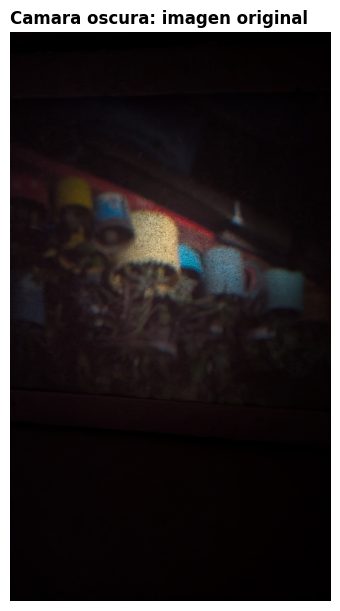

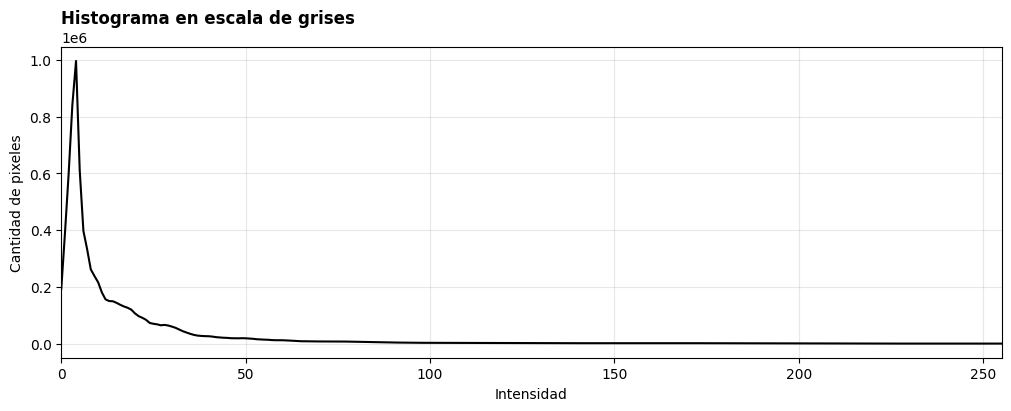

Diagnostico inicial: La imagen está invertida, tiene un fondo negro muy dominante alrededor de la proyección. En la zona central se observan colores identificables y se distinguen las macetas, pero la imagen es borrosa en general.Además, no se ven detalles en los bordes, aún más en los objetos alejados del centro.
Primera hipotesis: Recortar primero para eliminar el fondo negro y concentrarse en la región de la imagen proyectada. Luego comparar dos estrategias de mejora de contraste para recuperar información de las zonas subexpuestas con convertScaleAbs vs CLAHE.


In [ ]:
# Escribi aca el nombre de tu archivo para el caso de camara oscura.
nombre_imagen_camara_oscura = "imagen_caso_01.jpg"

# Inicializamos la variable de imagen para evitar errores si todavia no cargaste el archivo.
imagen_camara_oscura_rgb = None

# Cargamos la imagen solo si escribiste un nombre valido.
if nombre_imagen_camara_oscura != "":
    ruta_camara_oscura = carpeta_imagenes_tfi / nombre_imagen_camara_oscura
    imagen_camara_oscura_rgb = cargar_rgb(ruta_camara_oscura)

    # Mostramos la imagen original y su histograma para empezar el diagnostico.
    mostrar_imagen(imagen_camara_oscura_rgb, "Camara oscura: imagen original")
    mostrar_histograma_gris(imagen_camara_oscura_rgb)

# Escribi aca tu diagnostico inicial.
diagnostico_camara_oscura = (
    "La imagen está invertida, tiene un fondo negro muy dominante alrededor de la proyección. "
    "En la zona central se observan colores identificables y se distinguen las macetas, "
    "pero la imagen es borrosa en general."
    "Además, no se ven detalles en los bordes, aún más en los objetos alejados del centro."
)

# Escribi aca tu primera hipotesis de mejora.
hipotesis_camara_oscura = (
    "Recortar e invertir primero para eliminar el fondo negro y concentrarse en la región de la imagen proyectada." 
    " Luego comparar dos estrategias de mejora de contraste para recuperar información de las zonas subexpuestas con convertScaleAbs vs CLAHE." 
)

print("Diagnostico inicial:", diagnostico_camara_oscura)
print("Primera hipotesis:", hipotesis_camara_oscura)


### Estrategia 1 para camara oscura

Completa este bloque con una primera via de mejora. Conviene que hagas visible cada paso y que lo nombres con claridad.


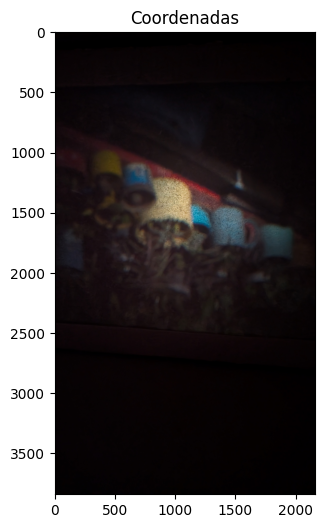

forma: (3840, 2160, 3)
tipo de dato uint8
valor mínimo 0
valor máximo 255


In [ ]:
# Previamente, observamos las coordenadas y su forma para decidir el recorte
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))
plt.imshow(imagen_camara_oscura_rgb)
plt.title("Coordenadas")
plt.axis("on")  
plt.show()

print ("forma:", imagen_camara_oscura_rgb.shape)
print ("tipo de dato", imagen_camara_oscura_rgb.dtype)
print ("valor mínimo", imagen_camara_oscura_rgb.min())
print ("valor máximo", imagen_camara_oscura_rgb.max())

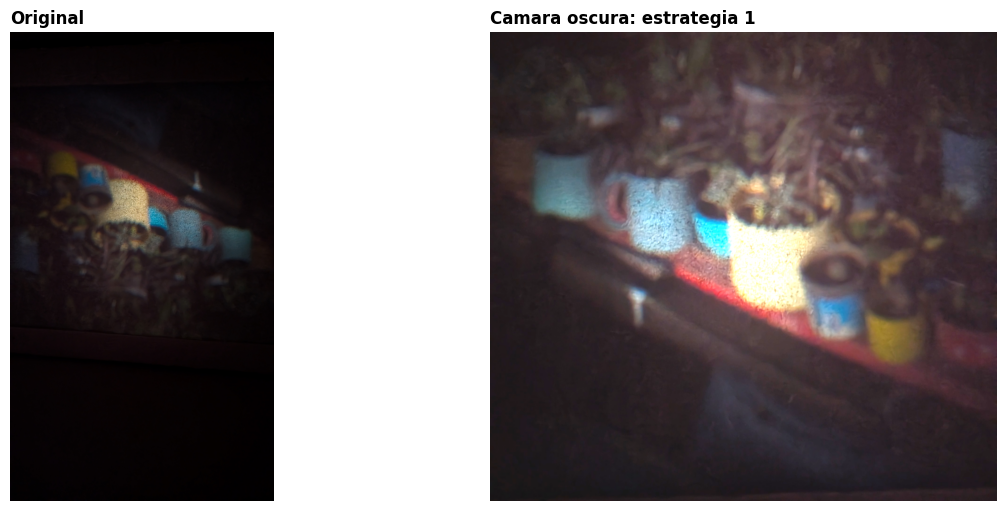

Si bien aumenté el contraste y el brillo para visualizar más el fondo, la parte central de la imagen se quemó bastante, así que agregué un paso 3 para suavizar el ruido con medianBlur.


In [ ]:
# Partimos de una copia de la imagen original si ya la cargaste.
imagen_camara_estrategia_1 = None
if imagen_camara_oscura_rgb is not None:
    imagen_camara_estrategia_1 = imagen_camara_oscura_rgb.copy()

    # Estrategia 1: Recortar y girar la imagen, además de utilizar brillo y contraste en forma global

    # Paso 1: recortamos la región de la proyección e invertimos la imagen
    imagen_camara_estrategia_1 = imagen_camara_estrategia_1[400:2400, 0:2500]
    imagen_camara_estrategia_1 = cv2.flip(imagen_camara_estrategia_1, -1)

    # Paso 2: ajuste global de brillo y contraste
    imagen_camara_estrategia_1 = cv2.convertScaleAbs(imagen_camara_estrategia_1, alpha=1.8, beta=20)

    # Paso 3: después del ajuste, suavizamos el ruido que se hizo visible
    imagen_camara_estrategia_1 = cv2.medianBlur(imagen_camara_estrategia_1, 5)

    mostrar_comparacion(
        imagen_camara_oscura_rgb,
        imagen_camara_estrategia_1,
        "Original",
        "Camara oscura: estrategia 1"
    )

# Describi brevemente que buscabas con esta estrategia.
observacion_camara_estrategia_1 = (
    "Si bien aumenté el contraste y el brillo para visualizar más el fondo, la parte central de la imagen se quemó bastante, así que "
    "agregué un paso 3 para suavizar el ruido con medianBlur."
)
print(observacion_camara_estrategia_1)


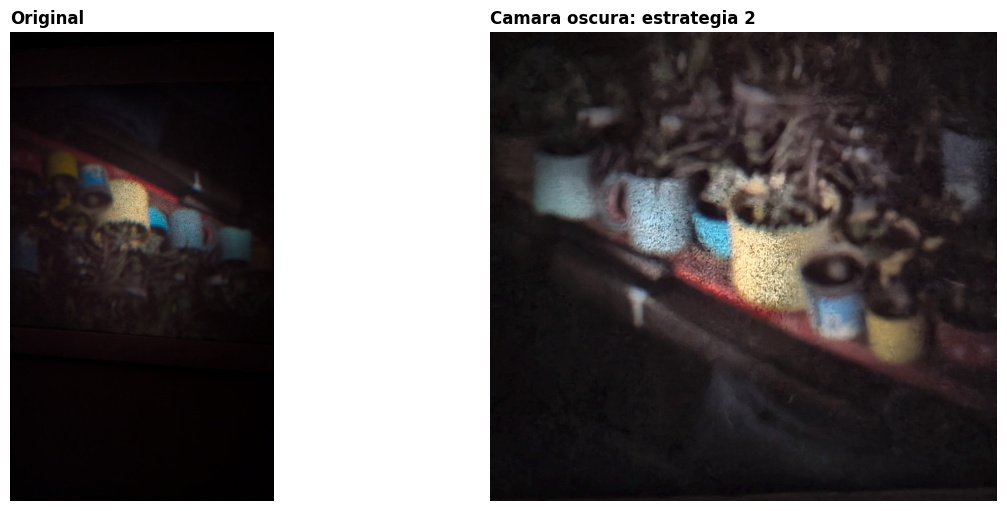

Luego del recorte e inversión, pasé la imagen por CLAHE. Los colores de las macetas se mantienen y se observa una mejora en las zonas del fondo, se ven más hojas aunque con menos color verde.


In [ ]:
# Construimos una segunda estrategia para poder comparar de verdad.
imagen_camara_estrategia_2 = None
if imagen_camara_oscura_rgb is not None:
    imagen_camara_estrategia_2 = imagen_camara_oscura_rgb.copy()

    # Estrategia 2: Recortar y girar la imagen, y utilizar CLAHE para trabajar el contraste de forma sectorizada

    # Paso 1: recortamos la región de la proyección e invertimos la imagen
    imagen_camara_estrategia_2 = imagen_camara_estrategia_2[400:2400, 0:2500]
    imagen_camara_estrategia_2 = cv2.flip(imagen_camara_estrategia_2, -1)

    # Paso 2: CLAHE 
    lab = cv2.cvtColor(imagen_camara_estrategia_2, cv2.COLOR_RGB2LAB)
    l, a, b = cv2.split(lab)
    clahe = cv2.createCLAHE(clipLimit=2.5,tileGridSize=(8,8))
    l_mejorado = clahe.apply(l)
    lab_mejorado = cv2.merge([l_mejorado, a, b])
    imagen_camara_estrategia_2 = cv2.cvtColor(lab_mejorado, cv2.COLOR_LAB2RGB)

    mostrar_comparacion(
        imagen_camara_oscura_rgb,
        imagen_camara_estrategia_2,
        "Original",
        "Camara oscura: estrategia 2"
    )

# Explica en que cambia esta segunda opcion.
observacion_camara_estrategia_2 = (
    "Luego del recorte e inversión, pasé la imagen por CLAHE. Los colores de las macetas se mantienen y se observa"
    " una mejora en las zonas del fondo, se ven más hojas aunque con menos color verde."
)
print(observacion_camara_estrategia_2)


La estrategia 2 (CLAHE) mejora el contraste de forma local y se adapta a las zonas de la imagen.Allí se procesa según su propio contenido, lo que permite recuperar detalle en las areas subexpuestas originales sin que los colores de las macetas del centro se 'quemen'.La estrategia 1 (convertScaleAbs) aplica el mismo ajuste a toda la imagen por igual, lo que termina quemando la zona central que ya tenia suficiente brillo.


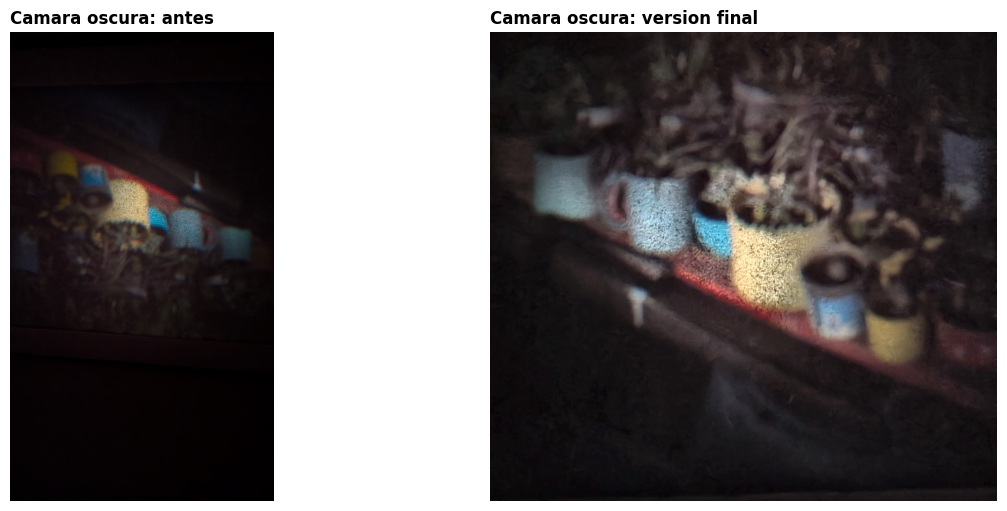

Salida guardada en: C:\Users\cin_c\OneDrive\Desktop\Repositorios\pdi\coronel-cintia-pdi-1c-2026\005 - TF1\salidas_tfi1\camara_oscura_final.png


In [295]:
# Elegi la version final para este caso.
imagen_camara_final = imagen_camara_estrategia_2

# Justifica por que conservas esta version.
justificacion_camara_final = (
    "La estrategia 2 (CLAHE) mejora el contraste de forma local y se adapta a las zonas de la imagen."
    "Allí se procesa según su propio contenido, lo que permite recuperar detalle en las "
    "areas subexpuestas originales sin que los colores de las macetas del centro se 'quemen'."
    "La estrategia 1 (convertScaleAbs) aplica el mismo ajuste a toda la imagen por igual, "
    "lo que termina quemando la zona central que ya tenia suficiente brillo."
    )
print(justificacion_camara_final)

# Guardamos la salida final solo si la imagen existe.
if imagen_camara_final is not None:
    ruta_salida_camara = carpeta_salidas_tfi / "camara_oscura_final.png"
    guardar_rgb(ruta_salida_camara, imagen_camara_final)

    if imagen_camara_oscura_rgb is not None:
        mostrar_comparacion(
            imagen_camara_oscura_rgb,
            imagen_camara_final,
            "Camara oscura: antes",
            "Camara oscura: version final"
        )

    print(f"Salida guardada en: {ruta_salida_camara.resolve()}")


## Caso 2. Imagen de medio grafico color

En este caso el problema puede estar en la geometria, en el contraste, en el color o en danos localizados. Antes de intervenir, conviene distinguir si el principal obstaculo es la perspectiva, la cromaticidad, la iluminacion o la presencia de manchas.

**Sugerencias tecnicas posibles:** rectificacion de perspectiva, mejora sobre HSV o LAB, `CLAHE`, suavizado e `inpainting` si hubiera dano localizado.


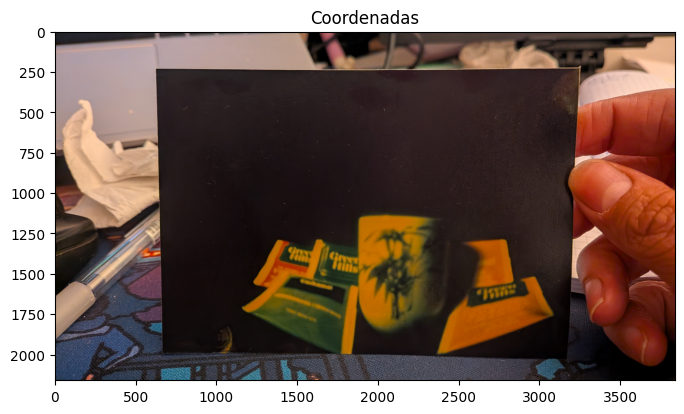

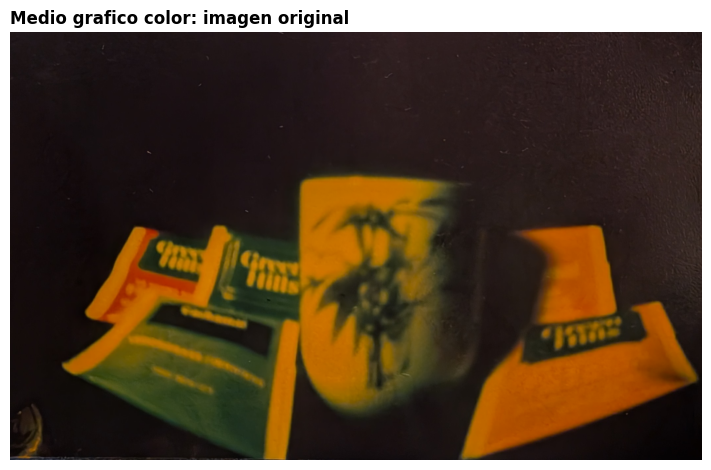

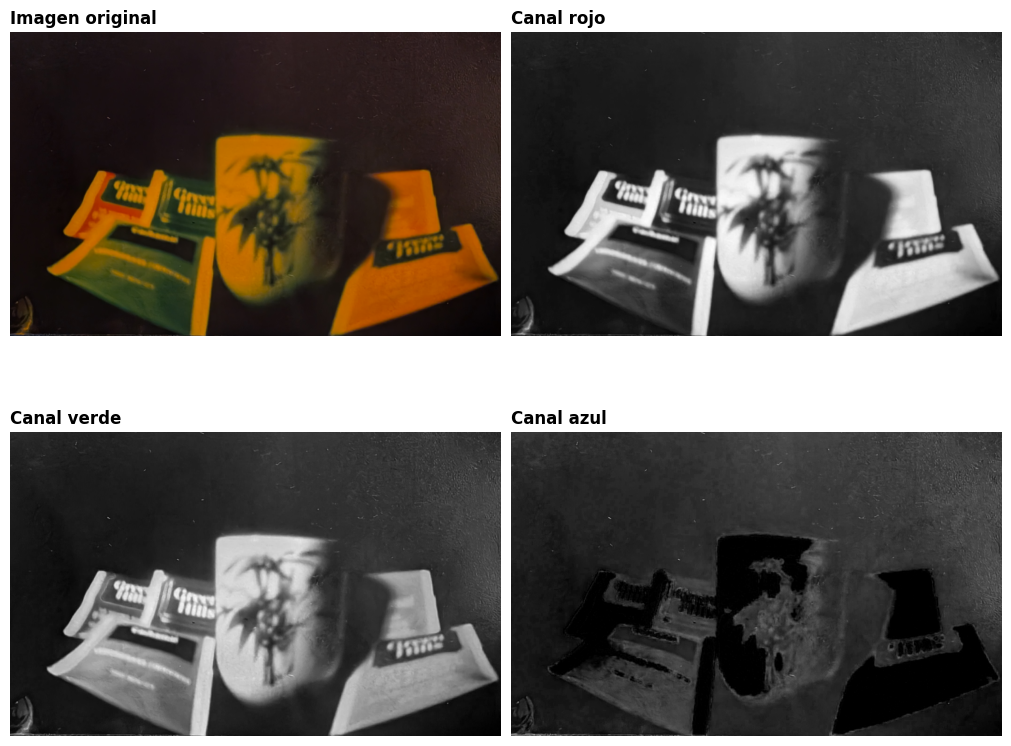

Diagnostico inicial: La imagen es predominantemente rojiza y verde, está borrosa (por el tipo de foto) y hay un desbalance en azul. Se nota la textura del papel.
Objetivo de mejora: Recuperar los colores de la imagen al corregir la predominancia en rojo y mejorar el contraste para que algunos elementos se diferencien más.


In [297]:
# Escribi aca el nombre de tu archivo para el caso de medio grafico color.
nombre_imagen_medio_color = "imagen_caso_02.jpg"

# Inicializamos la variable de imagen para evitar errores si todavia no cargaste el archivo.
imagen_medio_color_rgb = None

# Cargamos la imagen solo si escribiste un nombre valido.
if nombre_imagen_medio_color != "":
    ruta_medio_color = carpeta_imagenes_tfi / nombre_imagen_medio_color
    imagen_medio_color_rgb = cargar_rgb(ruta_medio_color)

    # Transformación previa de la imagen
    imagen_medio_color_rgb = cv2.rotate(imagen_medio_color_rgb, cv2.ROTATE_180)
    imagen_medio_color_rgb = cv2.flip(imagen_medio_color_rgb, -1)
    imagen_medio_color_rgb = cv2.flip(imagen_medio_color_rgb, 1)

    plt.figure(figsize=(8, 6))
    plt.imshow(imagen_medio_color_rgb)
    plt.title("Coordenadas")
    plt.axis("on")
    plt.show()

    imagen_medio_color_rgb = imagen_medio_color_rgb[700:2000, 1000:3100]

    # Mostramos la imagen original y sus canales para orientar el diagnostico.
    mostrar_imagen(imagen_medio_color_rgb, "Medio grafico color: imagen original")
    mostrar_canales_rgb(imagen_medio_color_rgb)

# Escribi aca el problema principal que detectaste.
diagnostico_medio_color = "La imagen es predominantemente rojiza y verde, está borrosa (por el tipo de foto) y hay un desbalance en azul. Se nota la textura del papel."

# Escribi aca que queres priorizar en la mejora.
objetivo_medio_color = "Recuperar los colores de la imagen al corregir la predominancia en rojo y mejorar el contraste para que algunos elementos se diferencien más."

print("Diagnostico inicial:", diagnostico_medio_color)
print("Objetivo de mejora:", objetivo_medio_color)


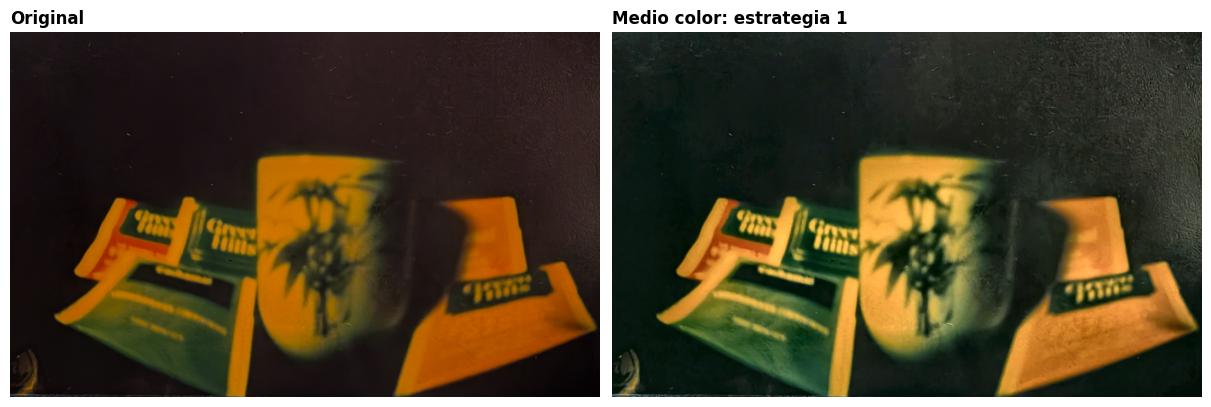

Corrección de canales en espacio LAB reduciendo el canal a y subiendo el b, y luego se aplicó CLAHE sobre el canal L. El rojo del fondo y de la imagen fue apagándose, pero comenzó a predominar el verde.Además, el naranja y el verde de los paquetes se diferencian mejor.La borrosidad y la textura del papel se mantienen como limitantes.


In [258]:
# Partimos de una copia de la imagen original si ya la cargaste.
imagen_medio_color_estrategia_1 = None
if imagen_medio_color_rgb is not None:
    imagen_medio_color_estrategia_1 = imagen_medio_color_rgb.copy()

    # Paso 1: corregir dominante en espacio LAB
    lab = cv2.cvtColor(imagen_medio_color_estrategia_1, cv2.COLOR_RGB2LAB).astype(np.float32)
    l, a, b = cv2.split(lab)
    a = np.clip(a - 10, 0, 255)  
    b = np.clip(b + 1, 0, 255)  
    lab_corregido = cv2.merge([l, a, b]).astype(np.uint8)
    imagen_medio_color_estrategia_1 = cv2.cvtColor(lab_corregido, cv2.COLOR_LAB2RGB)

    # Paso 2: CLAHE sobre canal L para mejorar contraste
    lab2 = cv2.cvtColor(imagen_medio_color_estrategia_1, cv2.COLOR_RGB2LAB)
    l2, a2, b2 = cv2.split(lab2)
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
    l2_mejorado = clahe.apply(l2)
    lab2_mejorado = cv2.merge([l2_mejorado, a2, b2])
    imagen_medio_color_estrategia_1 = cv2.cvtColor(lab2_mejorado, cv2.COLOR_LAB2RGB)

    mostrar_comparacion(
        imagen_medio_color_rgb,
        imagen_medio_color_estrategia_1,
        "Original",
        "Medio color: estrategia 1"
    )

observacion_medio_color_estrategia_1 = (
    "Corrección de canales en espacio LAB reduciendo el canal a y subiendo el b, "
    "y luego se aplicó CLAHE sobre el canal L. El rojo del fondo y de la imagen fue apagándose, pero comenzó a predominar el verde."
    "Además, el naranja y el verde de los paquetes se diferencian mejor."
    "La borrosidad y la textura del papel se mantienen como limitantes."
)

print(observacion_medio_color_estrategia_1)


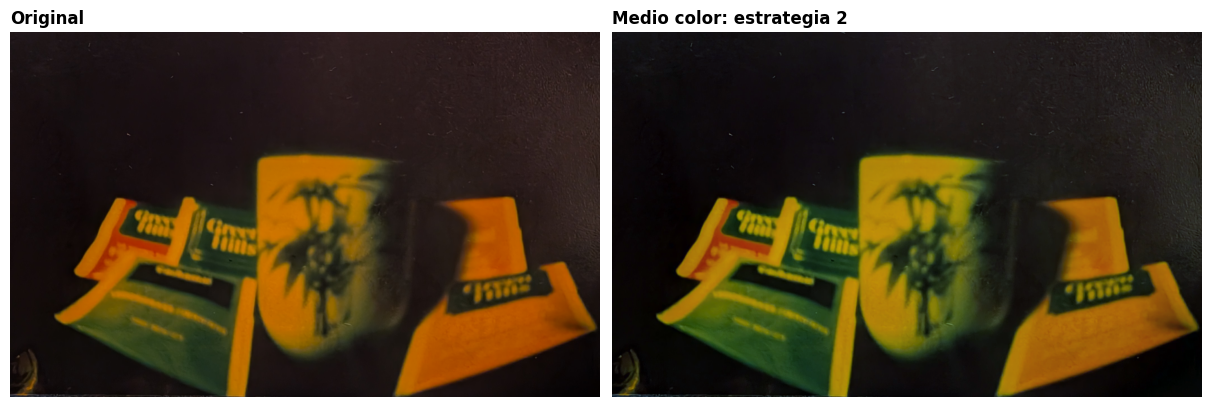

Reduccion del canal rojo seguida de ajuste de contraste con convertScaleAbs. Los colores se diferencian mejor como el naranja y el verde de los paquetes, el fondo perdió el tono rojo y quedó más oscuro. El contraste global mejoró aunque las zonas oscuras no llegan a negro pleno, de hecho la foto fue sacada con los objetos iluminados con luz directa.
Elijo la estrategia 2 porque la reducción del canal rojo corrige el desbalance de colores de forma más efectiva que la corrección en LAB, y el fondo queda más neutral. El ajuste global de contraste con convertScaleAbs diferencia mejor los elementos de la escena.


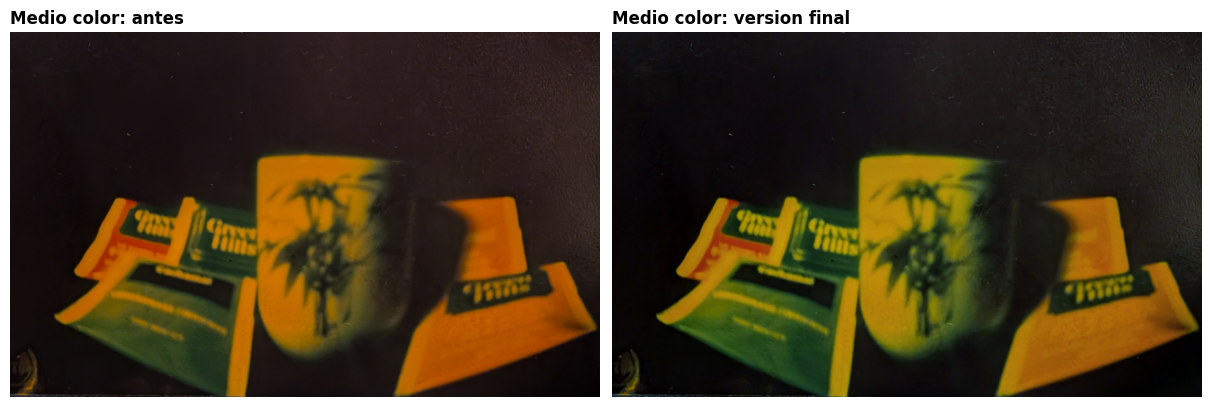

Salida guardada en: C:\Users\cin_c\OneDrive\Desktop\Repositorios\pdi\coronel-cintia-pdi-1c-2026\005 - TF1\salidas_tfi1\medio_grafico_color_final.png


In [298]:
# Construimos una segunda estrategia para poder discutir una eleccion.
imagen_medio_color_estrategia_2 = None
if imagen_medio_color_rgb is not None:
    imagen_medio_color_estrategia_2 = imagen_medio_color_rgb.copy()

    # Paso 1: reducir canal rojo directamente en RGB
    r, g, b = cv2.split(imagen_medio_color_estrategia_2)
    r = cv2.convertScaleAbs(r, alpha=0.75, beta=0)  # luego de varias pruebas, quedo con este valor del 75%
    imagen_medio_color_estrategia_2 = cv2.merge([r, g, b])

    # Paso 2: mejorar contraste global
    imagen_medio_color_estrategia_2 = cv2.convertScaleAbs(
    imagen_medio_color_estrategia_2, alpha=1.3, beta=-10
    )
    mostrar_comparacion(
        imagen_medio_color_rgb,
        imagen_medio_color_estrategia_2,
        "Original",
        "Medio color: estrategia 2"
    )

observacion_medio_color_estrategia_2 = (
    "Reduccion del canal rojo seguida de ajuste de contraste con "
    "convertScaleAbs. Los colores se diferencian mejor como el naranja y el verde "
    "de los paquetes, el fondo perdió el tono rojo y quedó más oscuro. "
    "El contraste global mejoró aunque las zonas oscuras no llegan a negro pleno, "
    "de hecho la foto fue sacada con los objetos iluminados con luz directa."
)
print(observacion_medio_color_estrategia_2)

# Elegi la version final para este caso.
imagen_medio_color_final = imagen_medio_color_estrategia_2

# Justifica por que conservas esta version.
justificacion_medio_color_final = (
    "Elijo la estrategia 2 porque la reducción del canal rojo corrige "
    "el desbalance de colores de forma más efectiva que la corrección en LAB, "
    "y el fondo queda más neutral. El ajuste global de contraste con convertScaleAbs "
    "diferencia mejor los elementos de la escena."
)
print(justificacion_medio_color_final)

# Guardamos la salida final solo si la imagen existe.
if imagen_medio_color_final is not None:
    ruta_salida_medio_color = carpeta_salidas_tfi / "medio_grafico_color_final.png"
    guardar_rgb(ruta_salida_medio_color, imagen_medio_color_final)

    if imagen_medio_color_rgb is not None:
        mostrar_comparacion(
            imagen_medio_color_rgb,
            imagen_medio_color_final,
            "Medio color: antes",
            "Medio color: version final"
        )

    print(f"Salida guardada en: {ruta_salida_medio_color.resolve()}")


## Caso 3. Imagen de medio grafico blanco/negro

En este caso suele importar la legibilidad. El objetivo es separar de manera razonable el fondo y los trazos, sin borrar informacion importante. Por eso conviene pensar si necesitas trabajar en grises, suavizar, umbralizar y limpiar la mascara resultante.

**Sugerencias tecnicas posibles:** conversion a grises, suavizado, umbral global, `Otsu`, `adaptiveThreshold`, apertura o clausura morfologica.


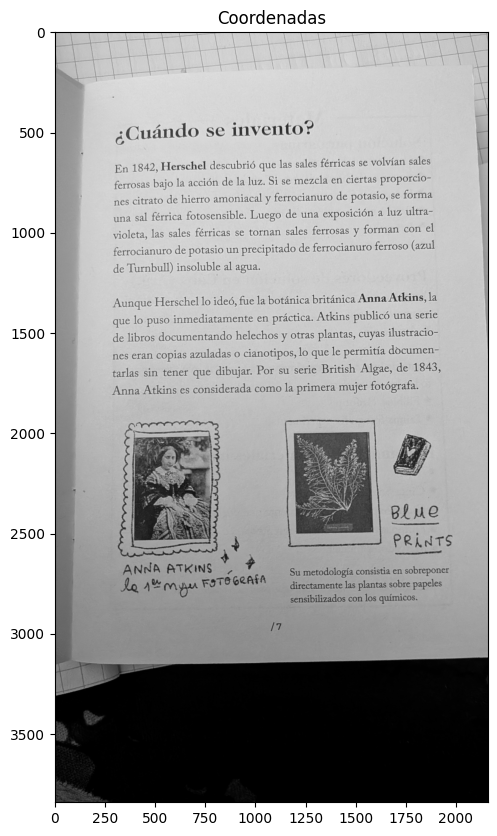

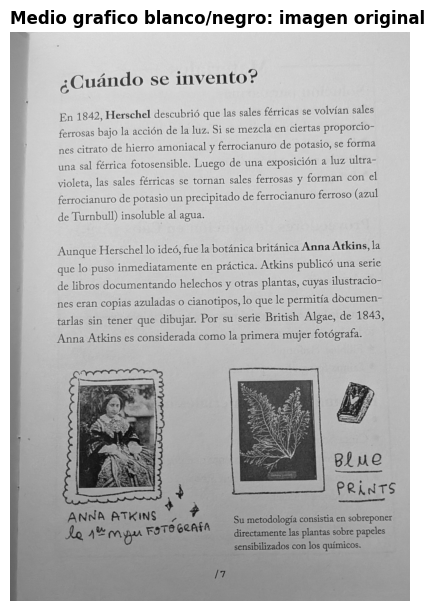

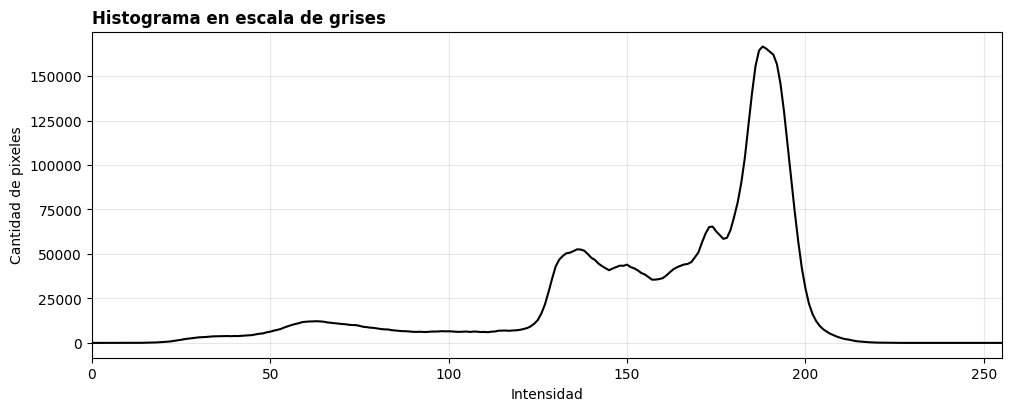

Diagnostico inicial: La imagen presenta iluminación desigual: el fondo varia entre grises y blancos según la zona, que también se ve en el histograma. Los trazos del texto e ilustraciones son bastantes clarosTambién hay una sombra a la izquierda y se nota la textura del papel. 
Objetivo de mejora: Suavizar primero para reducir ruido de la textura del papel, luego comparar dos estrategias de umbralización: Otsu contra adaptiveThreshold.


In [ ]:
# Escribi aca el nombre de tu archivo para el caso de medio grafico blanco/negro.
nombre_imagen_medio_bn = "imagen_caso_03.jpg"

# Inicializamos la variable de imagen para evitar errores si todavia no cargaste el archivo.
imagen_medio_bn_gris = None

# Cargamos la imagen solo si escribiste un nombre valido.
if nombre_imagen_medio_bn != "":
    ruta_medio_bn = carpeta_imagenes_tfi / nombre_imagen_medio_bn
    imagen_medio_bn_gris = cargar_gris(ruta_medio_bn)

    # Rotamos para que quede vertical
    imagen_medio_bn_gris = cv2.rotate(imagen_medio_bn_gris, cv2.ROTATE_90_COUNTERCLOCKWISE)

    # Mostramos con ejes para definir el recorte
    plt.figure(figsize=(8, 10))
    plt.imshow(imagen_medio_bn_gris, cmap="gray")
    plt.title("Coordenadas")
    plt.axis("on")
    plt.show()

    imagen_medio_bn_gris = imagen_medio_bn_gris[250:3100, 50:2050]

    # Mostramos la imagen original y su histograma para evaluar contraste y separación de tonos.
    mostrar_imagen(imagen_medio_bn_gris, "Medio grafico blanco/negro: imagen original")
    mostrar_histograma_gris(imagen_medio_bn_gris)

# Escribi aca el problema principal que detectaste.
diagnostico_medio_bn = (
    "La imagen presenta iluminación desigual: el fondo varia entre grises "
    "y blancos según la zona, que también se ve en el histograma. "
    "Los trazos del texto e ilustraciones son bastantes claros"
    "También hay una sombra a la izquierda y se nota la textura del papel. "
)

# Escribi aca que esperas recuperar o mejorar.
objetivo_medio_bn = (
    "Suavizar primero para reducir ruido de la textura del papel, luego comparar "
    "dos estrategias de umbralización: Otsu contra adaptiveThreshold." 
)

print("Diagnostico inicial:", diagnostico_medio_bn)
print("Objetivo de mejora:", objetivo_medio_bn)


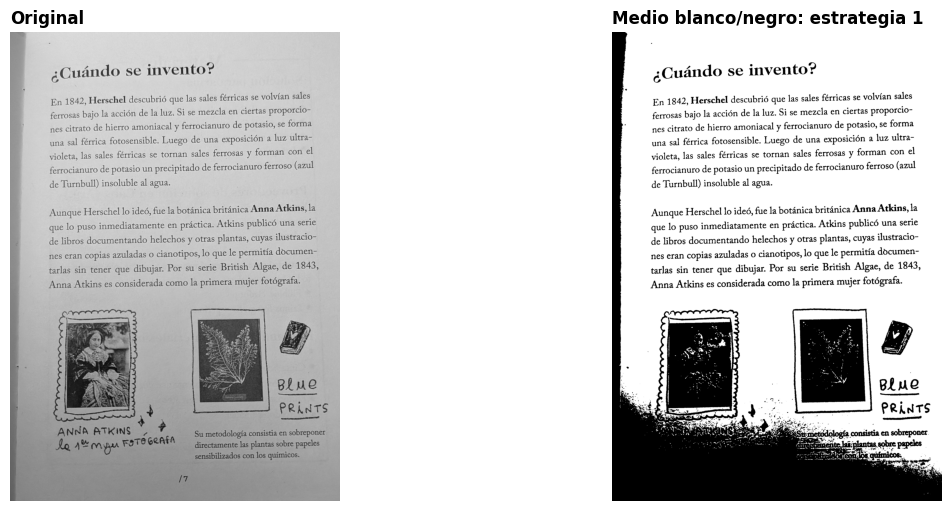

Luego del desenfoque gaussiano seguido de umbral global con Otsu se observa que la parte superior de la imagen tiene el texto legible y fondo limpio. Sin embargo, la zona inferior falla ya que la sombra original genera una región más oscura, lo que hace que se pierda legibilidad en el texto y llena de negro las ilustraciones. En este caso, el umbral global no es adecuado para imágenes con iluminación desigual.


In [272]:
# Construimos una primera estrategia para este caso.
imagen_medio_bn_estrategia_1 = None
if imagen_medio_bn_gris is not None:
    imagen_medio_bn_estrategia_1 = imagen_medio_bn_gris.copy()

    # Paso 1: suavizamos para reducir ruido de la textura del papel
    imagen_medio_bn_estrategia_1 = cv2.GaussianBlur(imagen_medio_bn_estrategia_1, (5, 5), 0)

    # Paso 2: umbral global con Otsu
    _, imagen_medio_bn_estrategia_1 = cv2.threshold(
        imagen_medio_bn_estrategia_1, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU
    )

    mostrar_comparacion(
        imagen_medio_bn_gris,
        imagen_medio_bn_estrategia_1,
        "Original",
        "Medio blanco/negro: estrategia 1"
    )

observacion_medio_bn_estrategia_1 = (
    "Luego del desenfoque gaussiano seguido de umbral global con Otsu se observa que la parte superior "
    "de la imagen tiene el texto legible y fondo limpio. "
    "Sin embargo, la zona inferior falla ya que la sombra original genera una región "
    "más oscura, lo que hace que se pierda legibilidad en el texto "
    "y llena de negro las ilustraciones. En este caso, el umbral global "
    "no es adecuado para imágenes con iluminación desigual."
)
print(observacion_medio_bn_estrategia_1)


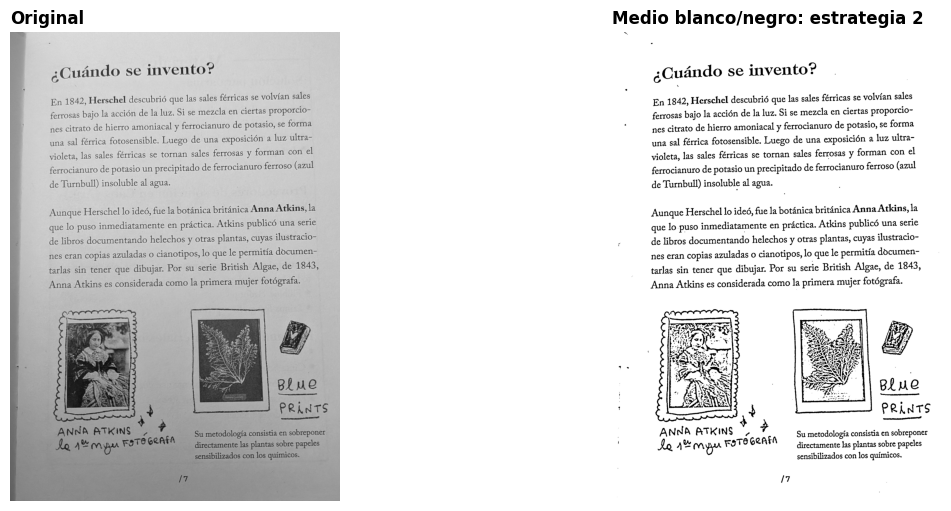

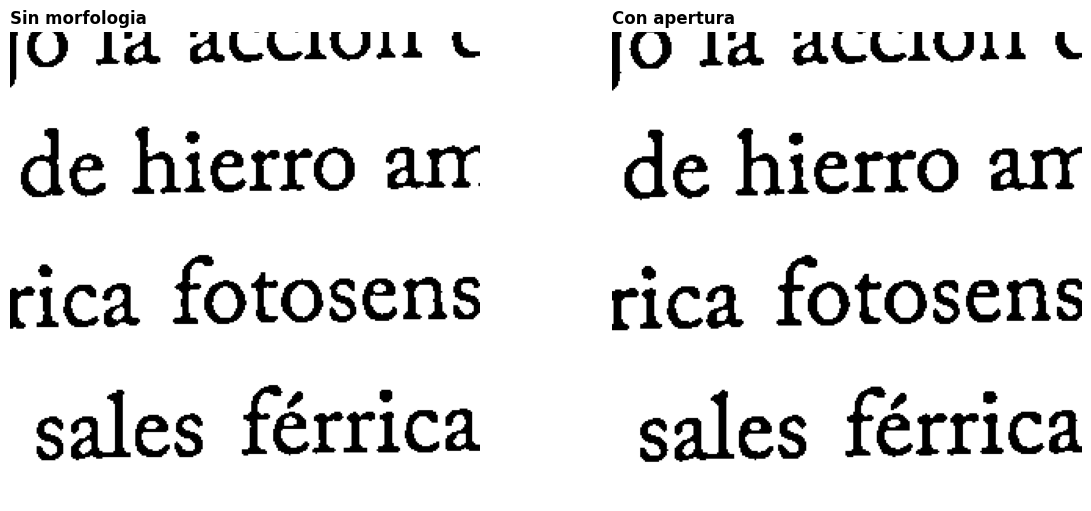

Desenfoque gaussiano seguido de adaptiveThreshold. En este caso, lailuminación despareja ya no se percibe en alguna de las acciones de esta estrategia.El texto es legible en toda la imagen incluyendo la zona inferior afectada donde tenemos la sombra. Los dibujos son entendibles, aunque parecen hechos con xilografía.
Elijo la estrategia 2 porque resuelve la iluminación desigual, el problema principal. Otsu trabaja en un único umbral global que falla en las zonas más oscuras por la sombra, perdiendo legibilidad del texto e imágenes. adaptiveThreshold trabaja calclando el umbral de forma local por zonas, lo que permite separar trazos del fondo de manera uniforme. La apertura morfológica complementa la umbralización eliminando ruido pequeño sin afectar los trazos.


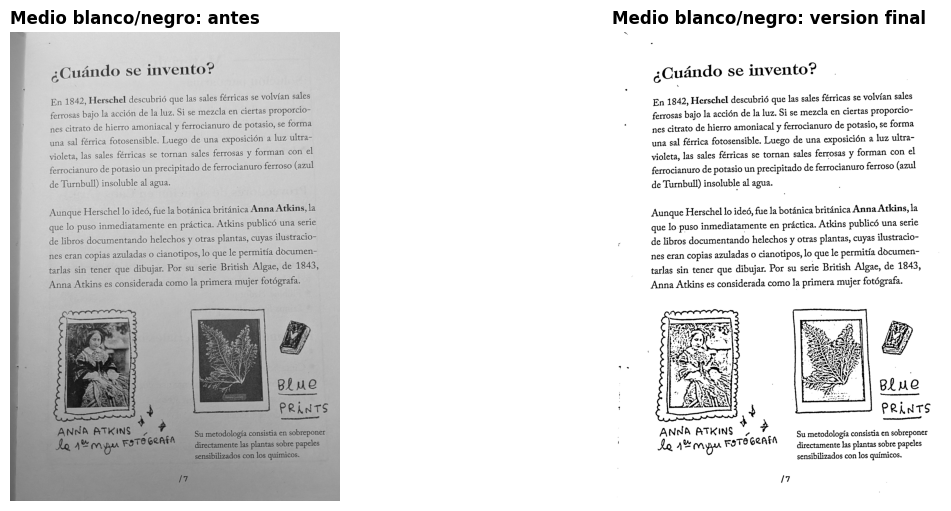

Salida guardada en: C:\Users\cin_c\OneDrive\Desktop\Repositorios\pdi\coronel-cintia-pdi-1c-2026\005 - TF1\salidas_tfi1\medio_grafico_bn_final.png


In [304]:
# Construimos una segunda estrategia distinta para comparar criterios.
imagen_medio_bn_estrategia_2 = None
if imagen_medio_bn_gris is not None:
    imagen_medio_bn_estrategia_2 = imagen_medio_bn_gris.copy()

    # Paso 1: suavizamos para reducir ruido de la textura del papel
    imagen_medio_bn_estrategia_2 = cv2.GaussianBlur(imagen_medio_bn_estrategia_2, (5, 5), 0)

    # Paso 2: umbral adaptativo por zonas
    imagen_medio_bn_estrategia_2 = cv2.adaptiveThreshold(
        imagen_medio_bn_estrategia_2,
        255,
        cv2.ADAPTIVE_THRESH_GAUSSIAN_C,
        cv2.THRESH_BINARY,
        blockSize=41, # probé con varios, en este caso considero que con 41 la imagen resultante es legible 
        C=10
    )

    # Paso 3: limpiamos el ruido pequeño con la apertura morfológica
    kernel = np.ones((2, 2), dtype=np.uint8)
    imagen_medio_bn_estrategia_2 = cv2.morphologyEx(
        imagen_medio_bn_estrategia_2, cv2.MORPH_OPEN, kernel, iterations=1
    )

    mostrar_comparacion(
        imagen_medio_bn_gris,
        imagen_medio_bn_estrategia_2,
        "Original",
        "Medio blanco/negro: estrategia 2"
    )

    # Paso 4: Análisis de antes y después de aplicar morfología
    # Antes de la apertura
    imagen_suavizada = cv2.GaussianBlur(imagen_medio_bn_gris, (5, 5), 0)
    imagen_sin_morfologia = cv2.adaptiveThreshold(
    imagen_suavizada,
    255, cv2.ADAPTIVE_THRESH_GAUSSIAN_C, cv2.THRESH_BINARY, 31, 10
    )

    # Comparamos una zona pequeña
    mostrar_comparacion(
        imagen_sin_morfologia[500:800, 500:800],
        imagen_medio_bn_estrategia_2[500:800, 500:800],
        "Sin morfologia",
        "Con apertura"
    )

observacion_medio_bn_estrategia_2 = (
    "Desenfoque gaussiano seguido de adaptiveThreshold. "
    "En este caso, lailuminación despareja ya no se percibe en alguna de las acciones de esta estrategia."
    "El texto es legible en toda la imagen incluyendo la zona inferior afectada "
    "donde tenemos la sombra. Los dibujos son entendibles, aunque parecen hechos con xilografía." 
)
print(observacion_medio_bn_estrategia_2)

# Elegi la version final para este caso.
imagen_medio_bn_final = imagen_medio_bn_estrategia_2

# Justifica por que conservas esta version.
justificacion_medio_bn_final = (
    "Elijo la estrategia 2 porque resuelve la iluminación desigual, el problema principal. " 
    "Otsu trabaja en un único umbral global que falla en las zonas más oscuras por la sombra, "
    "perdiendo legibilidad del texto e imágenes. adaptiveThreshold trabaja calclando "
    "el umbral de forma local por zonas, lo que permite separar trazos "
    "del fondo de manera uniforme. La apertura morfológica "
    "complementa la umbralización eliminando ruido pequeño sin afectar los trazos."
)

print(justificacion_medio_bn_final)

# Guardamos la salida final solo si la imagen existe.
if imagen_medio_bn_final is not None:
    ruta_salida_medio_bn = carpeta_salidas_tfi / "medio_grafico_bn_final.png"
    guardar_gris(ruta_salida_medio_bn, imagen_medio_bn_final)

    if imagen_medio_bn_gris is not None:
        mostrar_comparacion(
            imagen_medio_bn_gris,
            imagen_medio_bn_final,
            "Medio blanco/negro: antes",
            "Medio blanco/negro: version final"
        )

    print(f"Salida guardada en: {ruta_salida_medio_bn.resolve()}")




## Cierre comparativo

Ahora te toca salir del caso puntual y mirar el integrador como conjunto. La pregunta no es solo que funciono, sino tambien **por que convino una estrategia en un caso y no en otro**.


In [305]:
# Construimos una tabla de comparacion final entre los tres casos.
casos = [
    "Camara oscura",
    "Medio grafico color",
    "Medio grafico blanco/negro"
]

problemas_principales = [
    diagnostico_camara_oscura,
    diagnostico_medio_color,
    diagnostico_medio_bn
]

estrategias_finales = [
    justificacion_camara_final,
    justificacion_medio_color_final,
    justificacion_medio_bn_final
]

limites_detectados = [
    "Imagen borrosa, si bien está hecha a partir de una cámara oscura, costó sacar una foto a la proyección también.",
    "Imagen original borrosa y para este trabajo se hizo a partir de una foto sobre ella con el celular. La original se obtuvo a partir de una cámara estenopeica teniendo los objetos cerca, muy iluminados y en el estenopo había un filtro.",
    "La iluminación desigual del ambiente y la rugosidad del papel."
]

tabla_final = pd.DataFrame({
    "caso": casos,
    "problema_principal": problemas_principales,
    "decision_final": estrategias_finales,
    "limites": limites_detectados
})

display(tabla_final)


,caso,problema_principal,decision_final,limites
0,Camara oscura,"La imagen está invertida, tiene un fondo negro...",La estrategia 2 (CLAHE) mejora el contraste de...,"Imagen borrosa, si bien está hecha a partir de..."
1,Medio grafico color,"La imagen es predominantemente rojiza y verde,...",Elijo la estrategia 2 porque la reducción del ...,Imagen original borrosa y para este trabajo se...
2,Medio grafico blanco/negro,La imagen presenta iluminación desigual: el fo...,Elijo la estrategia 2 porque resuelve la ilumi...,La iluminación desigual del ambiente y la rugo...


## Reflexion final

Respondan con sus palabras:

1. ¿Que decision tecnica les resulto mas dificil de justificar y por que?
2. ¿En que caso la mejora fue mas clara y en cual fue mas limitada?
3. ¿Que aprendieron sobre la relacion entre tipo de degradacion y tipo de operacion?
4. ¿Que harian distinto si tuvieran una segunda iteracion de trabajo?

Es mera casualidad que todas las estrategias seleccionadas sean la opción 2.
1. La decisión más dificil fue elegir los parámetros para trabajar la corrección del color en el caso 2. De hecho, quedó como está en la entrega porque no supe hasta dónde o más corregir.
2. La mejora más clara fue en el caso 3, cada método proporciona una propuesta mucho más visible, distinguible y justificable, en este caso además por el factor iluminación.
En los casos 1 y 2 las mejoras fueron más limitadas por los medios (cámara oscura, cámara estenopeica y celular) e imágenes obtenidas. Además creo que quedaron similares las resoluciones.
3. Cada tipo de degradación necesita de una operación distinta, por lo que es importante detectar el problema que tiene la imagen.
- Si tenemos bajo contraste, CLAHE y convertScaleAbs nos sirven. 
- Si tenemos un desbalance en colores conviene trabajar por canales en LAB o RGB. 
- Si hay problemas con la iluminación despareja, sirve la umbralización adaptativa y no global. 
4. Corregiría las estrategias del canal 2 o buscaría otra imagen.


## Lista de control antes de entregar

- Resolvi los tres casos obligatorios.
- Mostre la imagen original en cada caso.
- Compare al menos dos estrategias por caso.
- Justifique la eleccion final de cada pipeline.
- Guarde las tres imagenes procesadas.
- Complete la tabla final de comparacion.
- Registre el uso de IA de manera breve y critica.
- Escribi una reflexion final con limites del metodo.

## Defensa oral breve

En la defensa cada integrante tiene que poder explicar el problema principal de cada caso, la razon de la estrategia elegida y el limite mas importante de la restauracion realizada.